In [1]:
import torch
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import QuantileLoss
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping
import pandas as pd
import numpy as np

print(f"PyTorch: {torch.__version__}")
print(f"GPU: {torch.cuda.is_available()}")
print(f"Dispositivo: {torch.cuda.get_device_name(0)}")

/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/pytorch_forecasting/models/base_model.py:27: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


PyTorch: 2.11.0+cu128
GPU: True
Dispositivo: NVIDIA GeForce RTX 5060 Ti


In [2]:
df_series = pd.read_parquet('/home/valentim/divea/data/processed/series_semanais.parquet')

df_tft = df_series[['casos']].copy().reset_index()
df_tft.columns = ['data', 'casos']
df_tft['time_idx'] = range(len(df_tft))
df_tft['grupo'] = 'parana'
df_tft['casos'] = df_tft['casos'].astype(float)
df_tft['semana'] = df_tft['data'].dt.isocalendar().week.astype(str)
df_tft['mes'] = df_tft['data'].dt.month.astype(str)

JANELA = 16
HORIZONTE = 4
SPLIT = int(len(df_tft) * 0.7)

print(f"Total: {len(df_tft)} | Treino: {SPLIT} | Teste: {len(df_tft) - SPLIT}")
print(df_tft.head())

Total: 382 | Treino: 267 | Teste: 115
        data  casos  time_idx   grupo semana mes
0 2018-12-31   13.0         0  parana      1  12
1 2019-01-07   39.0         1  parana      2   1
2 2019-01-14   51.0         2  parana      3   1
3 2019-01-21   29.0         3  parana      4   1
4 2019-01-28   45.0         4  parana      5   1


In [3]:
from pytorch_forecasting.data import GroupNormalizer

treino = TimeSeriesDataSet(
    df_tft[df_tft['time_idx'] <= SPLIT],
    time_idx='time_idx',
    target='casos',
    group_ids=['grupo'],
    min_encoder_length=JANELA,
    max_encoder_length=JANELA,
    min_prediction_length=HORIZONTE,
    max_prediction_length=HORIZONTE,
    time_varying_known_categoricals=['semana', 'mes'],
    time_varying_unknown_reals=['casos'],
    target_normalizer=GroupNormalizer(groups=['grupo'], transformation='softplus'),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validacao = TimeSeriesDataSet.from_dataset(
    treino, df_tft, predict=True, stop_randomization=True
)

train_loader = treino.to_dataloader(train=True, batch_size=32, num_workers=0)
val_loader = validacao.to_dataloader(train=False, batch_size=32, num_workers=0)

print(f"Batches treino: {len(train_loader)}")
print(f"Batches validação: {len(val_loader)}")


Batches treino: 7
Batches validação: 1


In [4]:
tft = TemporalFusionTransformer.from_dataset(
    treino,
    learning_rate=0.03,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=QuantileLoss(),
    optimizer='adam',
    log_interval=10,
    reduce_on_plateau_patience=4,
)

print(f"Parametros do modelo: {tft.size()/1e3:.1f}k")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min'
)

trainer = Trainer(
    max_epochs=80,
    accelerator='gpu',
    devices=1,
    callbacks=[early_stop],
    enable_progress_bar=True,
    log_every_n_steps=1,
)

trainer.fit(tft, train_loader, val_loader)
print("Treinamento concluido.")

/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason,

Parametros do modelo: 66.6k



   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 867    | train | 0    
3  | prescalers                         | ModuleDict                      | 160    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 5.7 K  | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 4.3 K  | train | 0    
6  | decoder_variable_selection         | VariableSelectionNetwork        | 2.3 K  | train | 0    
7  | static_context_variable_selection  | GatedResidualNetwork            | 4.3 K  | train | 0    
8  

Sanity Checking DataLoader 0:   0%|                                                               | 0/1 [00:00<?, ?it/s]

/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 0: 100%|████████████████████████████████████████████| 7/7 [00:00<00:00, 17.32it/s, v_num=3, train_loss_step=487.0]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|████| 7/7 [00:00<00:00, 29.22it/s, v_num=3, train_loss_step=362.0, val_loss=244.0, train_loss_epoch=559.0]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|████| 7/7 [00:00<00:00, 29.47it/s, v_num=3, train_loss_step=265.0, val_loss=165.0, train_loss_epoch=375.0]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                   

AttributeError: 'ExperimentWriter' object has no attribute 'add_embedding'

In [5]:
from lightning.pytorch.loggers import CSVLogger

tft = TemporalFusionTransformer.from_dataset(
    treino,
    learning_rate=0.03,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=QuantileLoss(),
    optimizer='adam',
    log_interval=-1,
    reduce_on_plateau_patience=4,
)

print(f"Parametros do modelo: {tft.size()/1e3:.1f}k")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min'
)

trainer = Trainer(
    max_epochs=80,
    accelerator='gpu',
    devices=1,
    callbacks=[early_stop],
    enable_progress_bar=True,
    log_every_n_steps=1,
    logger=CSVLogger(save_dir='/home/valentim/divea/logs/tft'),
)

trainer.fit(tft, train_loader, val_loader)
print("Treinamento concluido.")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   

Parametros do modelo: 66.6k
Epoch 0: 100%|████████████████████████████████████████████| 7/7 [00:00<00:00, 28.92it/s, v_num=0, train_loss_step=459.0]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|████| 7/7 [00:00<00:00, 29.47it/s, v_num=0, train_loss_step=467.0, val_loss=413.0, train_loss_epoch=566.0]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|████| 7/7 [00:00<00:00, 29.43it/s, v_num=0, train_loss_step=412.0, val_loss=293.0, train_loss_epoch=474.0]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Vali

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE semana +1: 447.5
MAE semana +2: 294.8
MAE semana +3: 312.1
MAE semana +4: 598.8


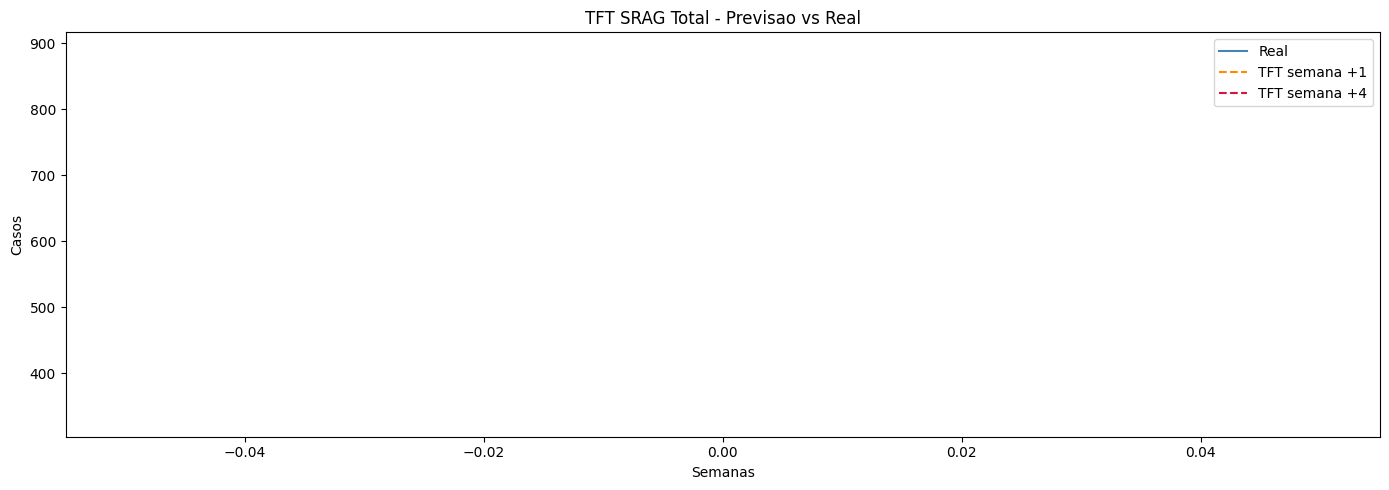

In [8]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

predictions = tft.predict(val_loader, return_y=True)
pred = predictions.output.cpu().numpy()
real = predictions.y[0].cpu().numpy()

# MAE por horizonte
for h in [0, 1, 2, 3]:
    mae = mean_absolute_error(real[:, h], pred[:, h])
    print(f"MAE semana +{h+1}: {mae:.1f}")

# Gráfico
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(real[:, 0], label='Real', color='steelblue', linewidth=1.5)
ax.plot(pred[:, 0], label='TFT semana +1', color='darkorange', linewidth=1.5, linestyle='--')
ax.plot(pred[:, 3], label='TFT semana +4', color='crimson', linewidth=1.5, linestyle='--')
ax.set_title('TFT SRAG Total - Previsao vs Real')
ax.set_xlabel('Semanas')
ax.set_ylabel('Casos')
ax.legend()
plt.tight_layout()
plt.savefig('/home/valentim/divea/outputs/tft_srag_total.png', dpi=150)
plt.show()

In [9]:
print(f"Shape pred: {pred.shape}")
print(f"Shape real: {real.shape}")
print(f"Primeiros valores pred: {pred[0]}")
print(f"Primeiros valores real: {real[0]}")

Shape pred: (1, 4)
Shape real: (1, 4)
Primeiros valores pred: [779.48035 756.79333 786.121   888.7655 ]
Primeiros valores real: [332. 462. 474. 290.]


In [10]:
SPLIT = int(len(df_tft) * 0.8)

treino = TimeSeriesDataSet(
    df_tft[df_tft['time_idx'] <= SPLIT],
    time_idx='time_idx',
    target='casos',
    group_ids=['grupo'],
    min_encoder_length=JANELA,
    max_encoder_length=JANELA,
    min_prediction_length=HORIZONTE,
    max_prediction_length=HORIZONTE,
    time_varying_known_categoricals=['semana', 'mes'],
    time_varying_unknown_reals=['casos'],
    target_normalizer=GroupNormalizer(groups=['grupo'], transformation='softplus'),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validacao = TimeSeriesDataSet.from_dataset(
    treino, df_tft, predict=True, stop_randomization=True
)

train_loader = treino.to_dataloader(train=True, batch_size=32, num_workers=0)
val_loader = validacao.to_dataloader(train=False, batch_size=32, num_workers=0)

print(f"Treino: {SPLIT} | Teste: {len(df_tft) - SPLIT}")
print(f"Batches treino: {len(train_loader)}")
print(f"Batches validação: {len(val_loader)}")

Treino: 305 | Teste: 77
Batches treino: 8
Batches validação: 1


In [11]:
validacao = TimeSeriesDataSet.from_dataset(
    treino,
    df_tft[df_tft['time_idx'] > (SPLIT - JANELA)],
    stop_randomization=True,
    predict=False,
)

val_loader = validacao.to_dataloader(train=False, batch_size=32, num_workers=0)

print(f"Batches validação: {len(val_loader)}")
print(f"Amostras validação: {len(validacao)}")

Batches validação: 3
Amostras validação: 73


In [12]:
tft = TemporalFusionTransformer.from_dataset(
    treino,
    learning_rate=0.03,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=QuantileLoss(),
    optimizer='adam',
    log_interval=-1,
    reduce_on_plateau_patience=4,
)

print(f"Parametros: {tft.size()/1e3:.1f}k")

early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer = Trainer(
    max_epochs=80,
    accelerator='gpu',
    devices=1,
    callbacks=[early_stop],
    enable_progress_bar=True,
    log_every_n_steps=1,
    logger=CSVLogger(save_dir='/home/valentim/divea/logs/tft'),
)

trainer.fit(tft, train_loader, val_loader)
print("Treinamento concluido.")

/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/

Parametros: 66.6k
                                                                                                                        

/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 0: 100%|████████████████████████████████████████████| 8/8 [00:00<00:00, 28.89it/s, v_num=1, train_loss_step=435.0]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|████| 8/8 [00:00<00:00, 29.21it/s, v_num=1, train_loss_step=462.0, val_loss=368.0, train_loss_epoch=499.0]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|████| 8/8 [00:00<00:00, 29.04it/s, v_num=1, train_loss_step=258.0, val_loss=312.0, train_loss_epoch=404.0]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                   

In [13]:
predictions = tft.predict(val_loader, return_y=True)
pred = predictions.output.cpu().numpy()
real = predictions.y[0].cpu().numpy()

print(f"Shape pred: {pred.shape}")
print(f"Shape real: {real.shape}")

for h in [0, 1, 2, 3]:
    mae = mean_absolute_error(real[:, h], pred[:, h])
    print(f"MAE semana +{h+1}: {mae:.1f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(real[:, 0], label='Real', color='steelblue', linewidth=1.5)
ax.plot(pred[:, 0], label='TFT semana +1', color='darkorange', linewidth=1.5, linestyle='--')
ax.plot(pred[:, 3], label='TFT semana +4', color='crimson', linewidth=1.5, linestyle='--')
ax.set_title('TFT SRAG Total - Previsao vs Real')
ax.set_xlabel('Semanas')
ax.set_ylabel('Casos')
ax.legend()
plt.tight_layout()
plt.savefig('/home/valentim/divea/outputs/tft_srag_total.png', dpi=150)
plt.show()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/valentim/miniconda3/envs/tft/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 32 but got size 9 for tensor number 2 in the list.

In [14]:
tft.eval()
preds = []
reals = []

with torch.no_grad():
    for batch in val_loader:
        x, y = batch
        out = tft(x)
        # pegar mediana (quantil 0.5, índice 3 de 7 quantis)
        pred_batch = out.prediction[:, :, 3].cpu().numpy()
        real_batch = y[0].cpu().numpy()
        preds.append(pred_batch)
        reals.append(real_batch)

pred = np.concatenate(preds, axis=0)
real = np.concatenate(reals, axis=0)

print(f"Shape pred: {pred.shape}")
print(f"Shape real: {real.shape}")

for h in [0, 1, 2, 3]:
    mae = mean_absolute_error(real[:, h], pred[:, h])
    print(f"MAE semana +{h+1}: {mae:.1f}")

Shape pred: (73, 4)
Shape real: (73, 4)
MAE semana +1: 131.6
MAE semana +2: 148.2
MAE semana +3: 161.8
MAE semana +4: 184.1


In [15]:
tft.eval()
preds = []
reals = []

with torch.no_grad():
    for batch in val_loader:
        x, y = batch
        out = tft(x)
        # pegar mediana (quantil 0.5, índice 3 de 7 quantis)
        pred_batch = out.prediction[:, :, 3].cpu().numpy()
        real_batch = y[0].cpu().numpy()
        preds.append(pred_batch)
        reals.append(real_batch)

pred = np.concatenate(preds, axis=0)
real = np.concatenate(reals, axis=0)

print(f"Shape pred: {pred.shape}")
print(f"Shape real: {real.shape}")

for h in [0, 1, 2, 3]:
    mae = mean_absolute_error(real[:, h], pred[:, h])
    print(f"MAE semana +{h+1}: {mae:.1f}")

Shape pred: (73, 4)
Shape real: (73, 4)
MAE semana +1: 131.6
MAE semana +2: 148.2
MAE semana +3: 161.8
MAE semana +4: 184.1


In [16]:
tft.eval()
preds = []
reals = []

with torch.no_grad():
    for batch in val_loader:
        x, y = batch
        out = tft(x)
        # pegar mediana (quantil 0.5, índice 3 de 7 quantis)
        pred_batch = out.prediction[:, :, 3].cpu().numpy()
        real_batch = y[0].cpu().numpy()
        preds.append(pred_batch)
        reals.append(real_batch)

pred = np.concatenate(preds, axis=0)
real = np.concatenate(reals, axis=0)

print(f"Shape pred: {pred.shape}")
print(f"Shape real: {real.shape}")

for h in [0, 1, 2, 3]:
    mae = mean_absolute_error(real[:, h], pred[:, h])
    print(f"MAE semana +{h+1}: {mae:.1f}")

Shape pred: (73, 4)
Shape real: (73, 4)
MAE semana +1: 131.6
MAE semana +2: 148.2
MAE semana +3: 161.8
MAE semana +4: 184.1


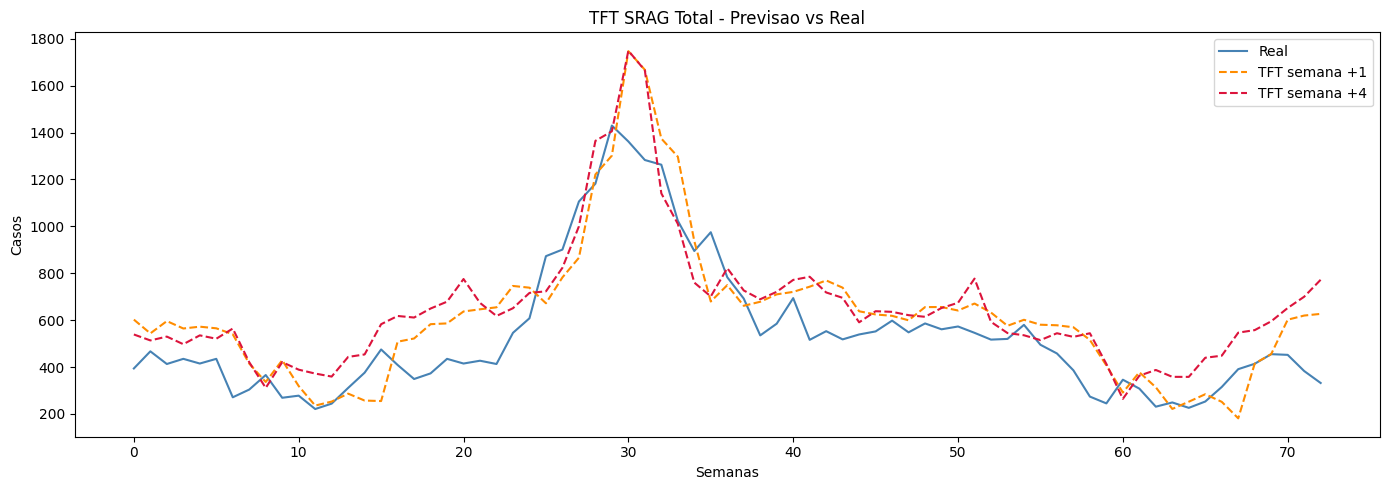

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(real[:, 0], label='Real', color='steelblue', linewidth=1.5)
ax.plot(pred[:, 0], label='TFT semana +1', color='darkorange', linewidth=1.5, linestyle='--')
ax.plot(pred[:, 3], label='TFT semana +4', color='crimson', linewidth=1.5, linestyle='--')
ax.set_title('TFT SRAG Total - Previsao vs Real')
ax.set_xlabel('Semanas')
ax.set_ylabel('Casos')
ax.legend()
plt.tight_layout()
plt.savefig('/home/valentim/divea/outputs/tft_srag_total.png', dpi=150)
plt.show()

In [ ]:
torch.save({
    'model_state': tft.state_dict(),
    'janela': JANELA,
    'horizonte': HORIZONTE,
    'config': {'hidden': 32, 'layers': 2, 'dropout': 0.1}
}, '/home/valentim/divea/models/tft_srag_total.pt')

print("Modelo TFT salvo.")